In [1]:
%load_ext autoreload
%autoreload 2   

import arviz as az
import numpy as np
import pandas as pd

from pyprojroot import here

import pymc as pm

import mmm_utils.plot as mmm_plot
import mmm_utils.post_modeling as mmm_post_plot
from mmm_utils import Timeline
from mmm_utils.data_logger import data_logger

data_logger.change_dir(here() / "work" / "logs")

## Loading the data and plotting spend and sales

In [2]:
file_path = here() / "examples" / "synthetic_mm_data.csv"
data = pd.read_csv(file_path, sep=";", decimal=".").fillna(0)

data["date"] = pd.to_datetime(data["date"])
data["intercept"] = 1
data["trend"] = np.linspace(0, 1, len(data))

media = ["TV", "SEA", "Digital"]
controls = ["intercept", "trend", "school_holidays", "price"]

X = data[media + controls + ["date"]]
y = data["y"]

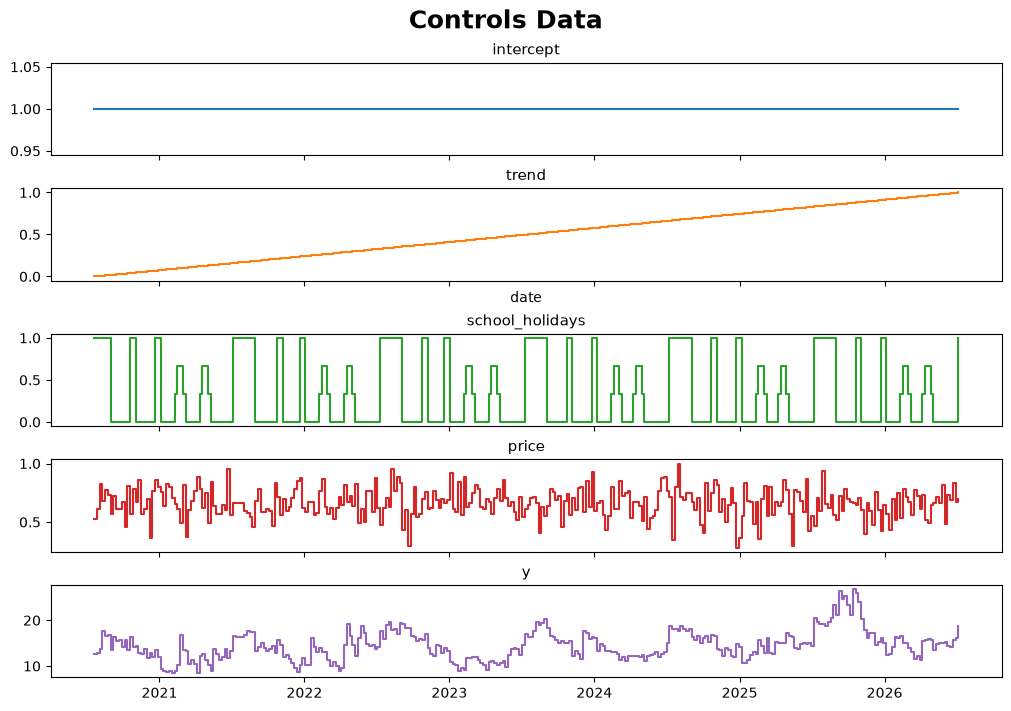

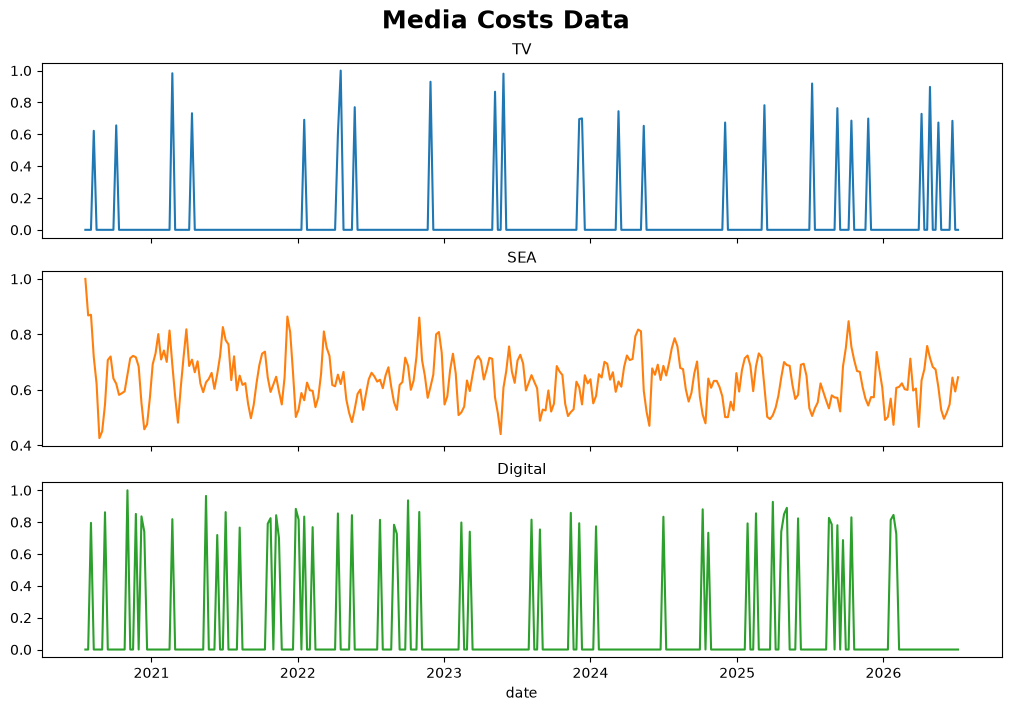

In [3]:
fig, axes = mmm_plot.plot_controls_variable(data, controls + ["y"])
fig, axes = mmm_plot.plot_media_costs(data, media)

## Modeling

In [4]:
from mmm_utils.modeling import MMM, MMMConfig, MediaTransformSpec
from mmm_utils.modeling.prior import PriorSpec, plot_prior_vs_posterior
from mmm_utils.modeling import Interaction, BetaPriors

In [5]:
interaction = Interaction(
    formulas={
        "TV": "1",
        "SEA": "1 + TV",
        "Digital": "1 + TV",
    },
    media=media,
    # is_shared_with=[("TV", "SEA", "Digital")],
)
print("Priors that need to be defined :")
interaction.get_unique_parameter_names()

Priors that need to be defined :


{'beta_interaction_TV'}

In [6]:
beta_priors = BetaPriors(
    interaction=interaction,
    priors={"beta_interaction_TV": PriorSpec("HalfNormal", {"sigma": 0.5})},
    season=PriorSpec("Laplace", {"mu": 0.0, "b": np.array([0.5, 0.5, 0.1, 0.1])}),
)

In [11]:
cfg = MMMConfig(
    media_names=media,
    control_names=controls,
    seasonality_order=2,
    beta_priors=beta_priors,
    media_transforms={
        "TV": MediaTransformSpec(
            adstock="Geometric",
            adstock_params={"l_max": 12},
            adstock_priors={
                "alpha": PriorSpec("Beta", {"alpha": 4.0, "beta": 0.5}),
                # "theta": PriorSpec("Normal", {"mu": 2, "sigma": 0.2}),
            },
            saturation="Logistic",
            saturation_params={},
            saturation_priors={
                "lam": PriorSpec("LogNormal", {"mu": 0.0, "sigma": 1.0})
            },
        ),
        "SEA": MediaTransformSpec(
            adstock="Geometric",
            adstock_params={"l_max": 12},
            adstock_priors={"alpha": PriorSpec("Beta", {"alpha": 2.0, "beta": 2.0})},
            saturation="Logistic",
            saturation_params={},
            saturation_priors={
                "lam": PriorSpec("LogNormal", {"mu": 0.0, "sigma": 1.0})
            },
        ),
        "Digital": MediaTransformSpec(
            adstock="Geometric",
            saturation="Logistic",
            saturation_params={},
            saturation_priors={
                "lam": PriorSpec("LogNormal", {"mu": 0.0, "sigma": 1.0})
            },
        ),
    },
)

mmm = MMM(cfg)

#### Model Building

In [12]:
mmm.build(X, y, rescale=True)

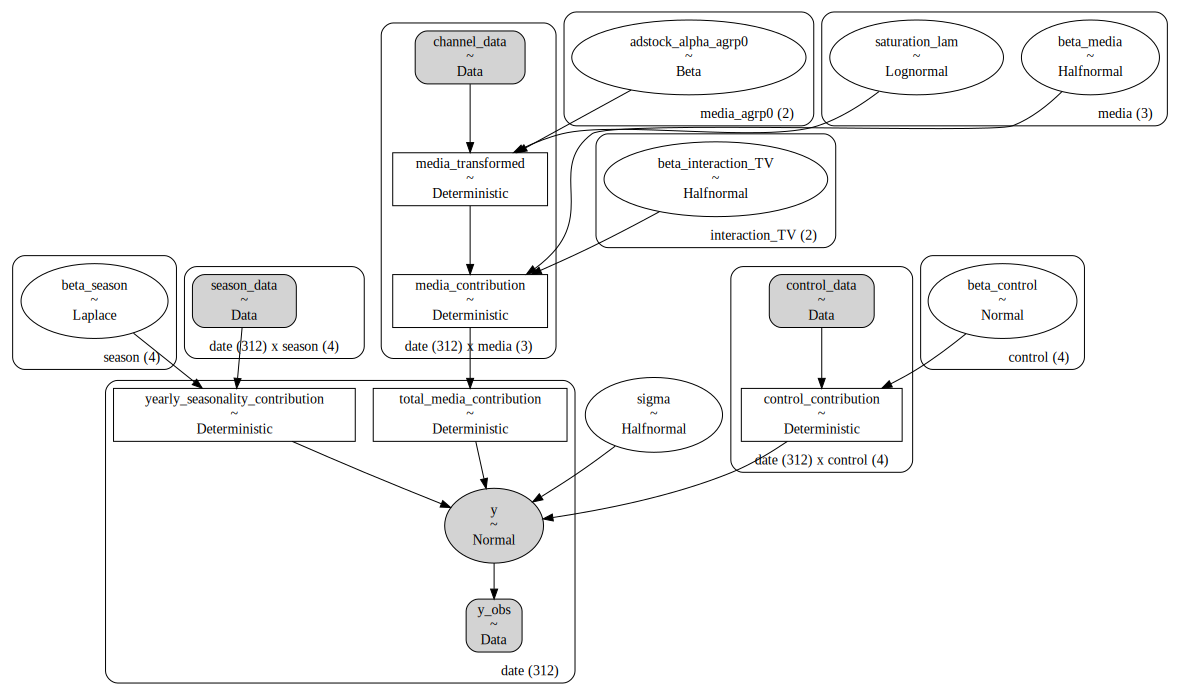

In [14]:
pm.model_to_graphviz(model=mmm.model, var_names=["y_obs"])

#### Model Fitting

In [15]:
mmm.fit(
    draws=500,
    tune=500,
    chains=1,
    cores=1,
    target_accept=0.975,
)

NUTS[numpyro]: [beta_interaction_TV, beta_media, beta_control, beta_season, adstock_alpha_agrp0, saturation_lam, sigma]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/usr/lib/python3.12/functools.py:909: UserWarning: Skipping Check{0 < alpha <= 1} Op (assertion: 0 < alpha <= 1) as JAX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:909: UserWarning: Skipping Check{lam must be positive} Op (assertion: lam must be positive) as JAX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
sample: 100%|██████████| 1000/1000 [01:14<00:00, 13.46it/s, 255 steps of size 8.71e-03. acc. prob=0.98]
/home/acaillebotte/projects/MMM/mmm_utils/.venv/lib/python3.12/site-packages/pymc/sampling/mcmc.py:995: FutureWarning: `passing log_likelihood` is deprecated and will be removed in future versions. Use :func:`pymc.compute_log_likelihood` instead.
  return _sample

In [16]:
mmm.sample_posterior_predictive()
_ = mmm.compute_contributions()

Sampling: [y]


Output()

Sampling: [adstock_alpha_agrp0, beta_control, beta_interaction_TV, beta_media, beta_season, saturation_lam, sigma, y]


Output()

In [17]:
post = mmm.idata.posterior

In [18]:
post.interaction_contributions

<xarray.DataArray 'interaction_contributions' (chain: 1, draw: 500, date: 312,
                                               media: 3)> Size: 4MB
array([[[[0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         ...,
         [0.34402627, 0.        , 0.        ],
         [0.27735082, 0.        , 0.        ],
         [0.25160401, 0.        , 0.        ]],

        [[0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         ...,
         [0.40808499, 0.        , 0.        ],
         [0.33039533, 0.        , 0.        ],
         [0.29619212, 0.        , 0.        ]],

        [[0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         ...,
...
         ...,
         [0.57724461, 0.        , 0.        ],
         [0.47695313, 0.        , 0.        ],
         [0.42673184, 0.        , 0.        ]],

        [[0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         ...,
         [0.89339283, 0.        , 0.        ],
         [0.73751623, 0.        , 0.        ],
         [0.66204123, 0.        , 0.        ]],

        [[0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         ...,
         [0.37588196, 0.        , 0.        ],
         [0.30760302, 0.        , 0.        ],
         [0.27305405, 0.        , 0.        ]]]], shape=(1, 500, 312, 3))
Coordinates:
  * chain    (chain) int64 8B 0
  * draw     (draw) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
  * date     (date) datetime64[us] 2kB 2020-07-20 2020-07-27 ... 2026-07-06
  * media    (media) <U7 84B 'TV' 'SEA' 'Digital'

## Post-modeling analysis

In [ ]:
fig, ax = mmm_post_plot.plot_posterior_predictive_y(
    mmm, add_seasonality=True, add_residuals=True
)

In [ ]:
az.residual_r2(mmm.idata, "y", group="posterior_predictive")

In [ ]:
def compute_mape(
    y_true: np.ndarray, y_pred: np.ndarray, epsilon: float = 1e-8
) -> float:
    """Compute Mean Absolute Percentage Error (MAPE).

    Parameters
    ----------
    y_true : np.ndarray
        Ground-truth target values.
    y_pred : np.ndarray
        Predicted target values.
    epsilon : float, default=1e-8
        Small value used to avoid division by zero.

    Returns
    -------
    float
        MAPE expressed as a percentage.
    """
    y_true_safe = np.where(np.abs(y_true) < epsilon, epsilon, y_true)
    return float(np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100.0)


posterior_predictive_mean = (
    mmm.idata.posterior_predictive["y"].mean(dim=["chain", "draw"]).values.squeeze()
)
y_true_values = y.to_numpy(dtype=float) / mmm.data.scale("y")

mape_score = compute_mape(y_true_values, posterior_predictive_mean)
print(f"MAPE: {mape_score:.2f}%")

## ROPE analysis & Estimation printing

In [ ]:
mmm_post_plot.rope_probability_test(
    posterior=mmm.idata.posterior,
    var=cfg.var_names(),
    rope=(-0.1, 0.1),
    verbatim=False,
)

In [ ]:
all_beta = mmm.idata.posterior.beta_media
data_logger.direct_to_csv(
    "posterior_beta_draws.csv", dataframe=all_beta.to_dataframe().reset_index()
)


import matplotlib.pyplot as plt


beta_media_samples = [
    all_beta.sel(media=media_name).values.reshape(-1) for media_name in media
]
positions = np.arange(1, len(media) + 1)
cmap = plt.get_cmap("tab10")
colors = cmap(np.linspace(0, 1, len(media)))

fig, ax = plt.subplots(figsize=(8, 5))

# Horizontal boxplot (background)
box_parts = ax.boxplot(
    beta_media_samples,
    positions=positions,
    widths=0.25,
    patch_artist=True,
    showfliers=False,
    vert=False,
    zorder=2,
)

# Horizontal violin plot (foreground)
violin_parts = ax.violinplot(
    beta_media_samples,
    positions=positions,
    showmeans=False,
    showmedians=False,
    showextrema=False,
    vert=False,
)

for idx in range(len(media)):
    patch = box_parts["boxes"][idx]
    patch.set_facecolor(colors[idx])
    patch.set_edgecolor("black")
    patch.set_alpha(0.75)

    body = violin_parts["bodies"][idx]
    body.set_facecolor(colors[idx])
    body.set_edgecolor("black")
    body.set_alpha(1.0)
    body.set_zorder(1)

# --- Mean ---
means = np.array([samples.mean() for samples in beta_media_samples])
ax.scatter(means, positions, color="black", marker="o", s=40, zorder=3)
# --- Median ---
medians = np.array([np.median(samples) for samples in beta_media_samples])
ax.scatter(medians, positions, color="black", marker="x", s=55, zorder=4)

ax.set_yticks(positions)
ax.set_yticklabels(media)
ax.set_xlabel("Posterior samples")
ax.set_ylabel("Media channel")
ax.set_title("Posterior distribution of beta_media by media channel")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()

In [ ]:
estim = (
    az.summary(data=mmm.idata, var_names=cfg.var_names())
    .reset_index()
    .rename(columns={"index": "parameter"})
)

value_columns = [col for col in estim.columns if col != "parameter"]
estim[value_columns] = (
    estim[value_columns].apply(pd.to_numeric, errors="coerce").astype(float)
)

In [ ]:
estim

In [ ]:
def robustness_check(estim, filter=None):
    def _classify(lo: float, hi: float, center: float) -> dict:
        """Return the level dict for the given ETI 89% bounds.

        Parameters
        ----------
        lo, hi   : ETI 89% lower / upper bounds (eti89_lb, eti89_ub).
        center   : posterior mean used as point estimate for relative width.
        """
        overlaps_zero = lo < 1e-9
        # Compute relative width as a fraction of the center (mean) value.
        rel_width = (hi - lo) / max(abs(center), 1e-9)

        if not overlaps_zero and rel_width <= 0.30:
            return "Robuste"
        if not overlaps_zero and rel_width <= 0.80:
            return "Acceptable"
        if overlaps_zero and rel_width > 0.80:
            return "Non identifié"
        return "Fragile"

    results = []
    for _, row in estim.iterrows():
        level = _classify(row["eti89_lb"], row["eti89_ub"], row["mean"])
        results.append({"parameter": row["parameter"], "robustness_level": level})

    if filter is not None:
        results = [r for r in results if r["robustness_level"] == filter]

    return pd.DataFrame(results)


robustness_check(estim, "Fragile")

In [ ]:
high_mcse_variables = mmm_post_plot.summarize_high_mcse_mean(estim)

high_mcse_variables.round({"mcse_over_sd": 2})

In [ ]:
# signal_std = np.std(y_true)
# noise_std = estim.loc[estim["parameter"] == "sigma", "mean"].values[0]
# snr = signal_std / noise_std

# print(f"Signal std: {signal_std:.4f}")
# print(f"Noise std (sigma): {noise_std:.4f}")
# print(f"Signal-to-Noise Ratio (SNR): {snr:.2f}")

In [ ]:
mmm_post_plot.adstock_to_half_life(mmm, media).round(
    {"adstock_alpha": 3, "half_life": 2}
)

## Ploting priors and posteriors

In [ ]:
def plot_params_prior_cs_posterior(var_prefix, seperately=True):
    media_found = [m for m in media if f"{var_prefix}[{m}]" in cfg.var_names()]
    if len(media_found) == 0:
        return None

    return plot_prior_vs_posterior(
        mmm,
        var_prefix,
        media_found,
        seperately=seperately,
    )

In [ ]:
plot_prior_vs_posterior(
    mmm, "beta_interaction_TV", None, separately=False, figsize=(6, 6)
)

In [ ]:
plot_prior_vs_posterior(mmm, "beta_media", media, seperately=True)
plot_prior_vs_posterior(mmm, "beta_control", controls, seperately=True)
plot_prior_vs_posterior(
    mmm,
    "beta_season",
    mmm.idata.posterior.season.values,
    seperately=False,
    figsize=(12, 6),
)
plot_params_prior_cs_posterior("saturation_n")
plot_params_prior_cs_posterior("saturation_k")
plot_params_prior_cs_posterior("saturation_lam")
plot_params_prior_cs_posterior("adstock_alpha")
plot_params_prior_cs_posterior("adstock_theta")
plot_params_prior_cs_posterior("umbrella")

### Adstock Effects Interpretation

In [ ]:
fig, ax = mmm_post_plot.plot_adstock_effects(data, mmm, media=media)

## Timeline

In [ ]:
timeline = Timeline(
    mmm.idata.posterior,
    data,
    media=media,
    controls=["trend", "school_holidays", "price"],
    baseline_components=["intercept", "yearly_seasonality"],
    target_scale=mmm.data.scale("y"),
    target="y",
)

timeline.outcome_df.head()

In [ ]:
fig, ax = mmm_plot.plot_contributions(
    timeline,
    channels=media + ["trend", "price", "school_holidays"],
    decomposition=False,
    plot_y=True,
    remove_baseline=False,
    ascending=False,
)

In [ ]:
_ = mmm_plot.plot_summary_contributions(
    timeline,
    controls=[],
    baseline_override=[],
)

_ = mmm_plot.plot_summary_contributions_per_media(
    timeline, controls=["trend", "promo", "price"]
)

# Saturation & Optimization

In [ ]:
saturation_curves = mmm.sample_saturation_curves(x_max=2.0)

In [ ]:
media_scales = mmm.data.scale("media")

saturation = []
for i, m in enumerate(media):
    curve = saturation_curves[m]
    sat_name = f"saturation_{m}"

    xx = (curve.coords["x"]).values * media_scales[m]
    beta = (
        mmm.idata.posterior[f"beta_media"]
        .sel(media=m)
        .mean(dim=["chain", "draw"])
        .values
    )
    yy = beta * curve.mean(dim=["chain", "draw"]).values * mmm.data.scale("y")

    saturation.append(
        {
            "name": m,
            "values": {str(int(xx[k])): float(yy[k]) for k in range(len(xx))},
        }
    )

_ = plot_saturation_curves(saturation_curves, mmm, data=data, media=media)

In [ ]:
from mmm_utils.optimizer.optimizer import Optimizer
import xarray as xr

current_budget = data[media].mean().to_dict()

optimizer = Optimizer(mmm)

optimizer.set_campaign(
    starting_date=data["date"].max() + pd.Timedelta(weeks=1),
    campaign_period=4,
    budget_by_media=current_budget,
)

flexibilities = {"low": 0.2, "medium": 0.4, "high": 0.6}

total_budget = sum(current_budget.values()) * 4
print(f"total budget = {total_budget}")


def get_recommended_budget(flex):
    print(flex)

    def lower_upper_bound(b, f):  # pylint: disable=missing-function-docstring, missing-return-doc
        return [b * (1 - f), b * (1 + f)]

    budget_bounds = [lower_upper_bound(b, flex) for _, b in current_budget.items()]

    budget_optimized_cst, res_cst = optimizer.optimize(
        budget_bounds,
        total_budget,
        constant_budget=True,
    )

    return budget_optimized_cst


all_budgets = {
    type: get_recommended_budget(flexibilities[type])[0, :]
    for type in flexibilities.keys()
}

In [ ]:
total_budget = data[media].sum().to_dict()
plan = all_budgets["medium"]
x = pd.DataFrame(
    {
        "media": current_budget.keys(),
        "current_budget": current_budget.values(),
        "plan": plan,
    },
)

x["reco"] = x["plan"] / sum(x["current_budget"]) * 100
x["change"] = x["plan"] / x["current_budget"] * 100 - 100

x["current_budget"] = total_budget.values()
x["plan"] = x["reco"] * sum(x["current_budget"]) / 100

data_logger.direct_to_csv("budget_recommendations.csv", dataframe=x)
x.round({"current_budget": 0, "plan": 0, "reco": 1})

# Mongo

In [ ]:
1 / 0

In [ ]:
timeline = Timeline(
    mmm.idata.posterior,
    data=data,
    media=media,
    controls=[],
    target="y",
    baseline_components=controls + ["yearly_seasonality"],
    target_scale=mmm.data.scale("y"),
)
_ = mmm_plot.plot_summary_contributions_per_media(timeline)

_ = mmm_plot.plot_summary_contributions(
    timeline,
    controls=[],
    baseline_override=[],
)

In [ ]:
from datetime import datetime, UTC
import os
from pymongo import MongoClient
import pymongo
from dotenv import load_dotenv

load_dotenv()

CODE_MODULE = "MMM_ANTOINE"
DISPLAY_MONGO = {k: k for k in media}
recommendations = [
    {
        "name": m,
        "spend": {type: float(all_budgets[type][i]) for type in flexibilities.keys()},
    }
    for i, m in enumerate(media)
]
timeline_entries = timeline.timeline

In [ ]:
import json

# ============================================================
# 4. EXPORT MONGODB
# ============================================================

doc = {
    "code_module": CODE_MODULE,
    "created_at": datetime.utcnow(),
    "labels": {
        "currency": "",
        "outcome_unit": "kpi",
        "outcome_contribution": "Contribution des médias au KPI",
        "media_attributed_outcome": "KPI attribué aux médias",
        "cost_per_outcome": "Coût par KPI",
    },
    "mediagroups": {DISPLAY_MONGO[m]: [DISPLAY_MONGO[m]] for m in media},
    "recommendations": recommendations,
    "saturation": {
        "media": saturation,
        "details": saturation,
    },
    "timeline": timeline_entries,
    "version": 2,
}

logs_dir = here() / "logs"
logs_dir.mkdir(parents=True, exist_ok=True)

ts = datetime.now(UTC).strftime("%Y_%m%dT%Hh%Mm%Ss_%fZ")
json_path = logs_dir / f"{CODE_MODULE}_{ts}.json"


def _json_default(o):
    if isinstance(o, np.generic):
        return o.item()
    if isinstance(o, np.ndarray):
        return o.tolist()
    return str(o)


with open(json_path, "w", encoding="utf-8") as f:
    json.dump(doc, f, ensure_ascii=False, indent=2, default=_json_default)

print(f"📝 JSON saved: {json_path}")

# Connexion MongoDB (credentials Le Lab - Cosmos Azure)
MONGO_URI = os.environ.get("MONGO_URI")
print(MONGO_URI)
client = MongoClient(MONGO_URI)
db = client["lelab"]

last_entry = db["datas_modules"].find_one(
    {"code_module": doc["code_module"]},
    sort=[("created_at", -1)],
)
force_creation = False

if not last_entry or force_creation:  # No existing entry found, insert new document
    inserted_id = db["datas_modules"].insert_one(doc).inserted_id
    last_entry = db["datas_modules"].find_one({"_id": inserted_id})
    if last_entry is None:
        raise RuntimeError(
            f"Failed to create a new entry for code_module={doc['code_module']}"
        )
    else:
        print(
            f" Successfully created new entry for code_module={doc['code_module']} with _id={last_entry['_id']}"
        )
else:
    print(f"Found existing entry for code_module={doc['code_module']}, updating it.")

print(
    f"📝 MongoDB entry for code_module={doc['code_module']} updated/created with _id={last_entry['_id']} created at {last_entry['created_at']}"
)

In [ ]:
doc["created_at"] = datetime.now(UTC)

result = db["datas_modules"].update_one(
    {
        "code_module": doc["code_module"],
    },
    {"$set": doc},
    upsert=False,
)

print("=" * 50)
print("✅ Derniere entree mise a jour en base MongoDB")
print("=" * 50)
print(f"  code_module  : {doc['code_module']}")
print(f"  created_at   : {doc['created_at']}")

client.close()
print()